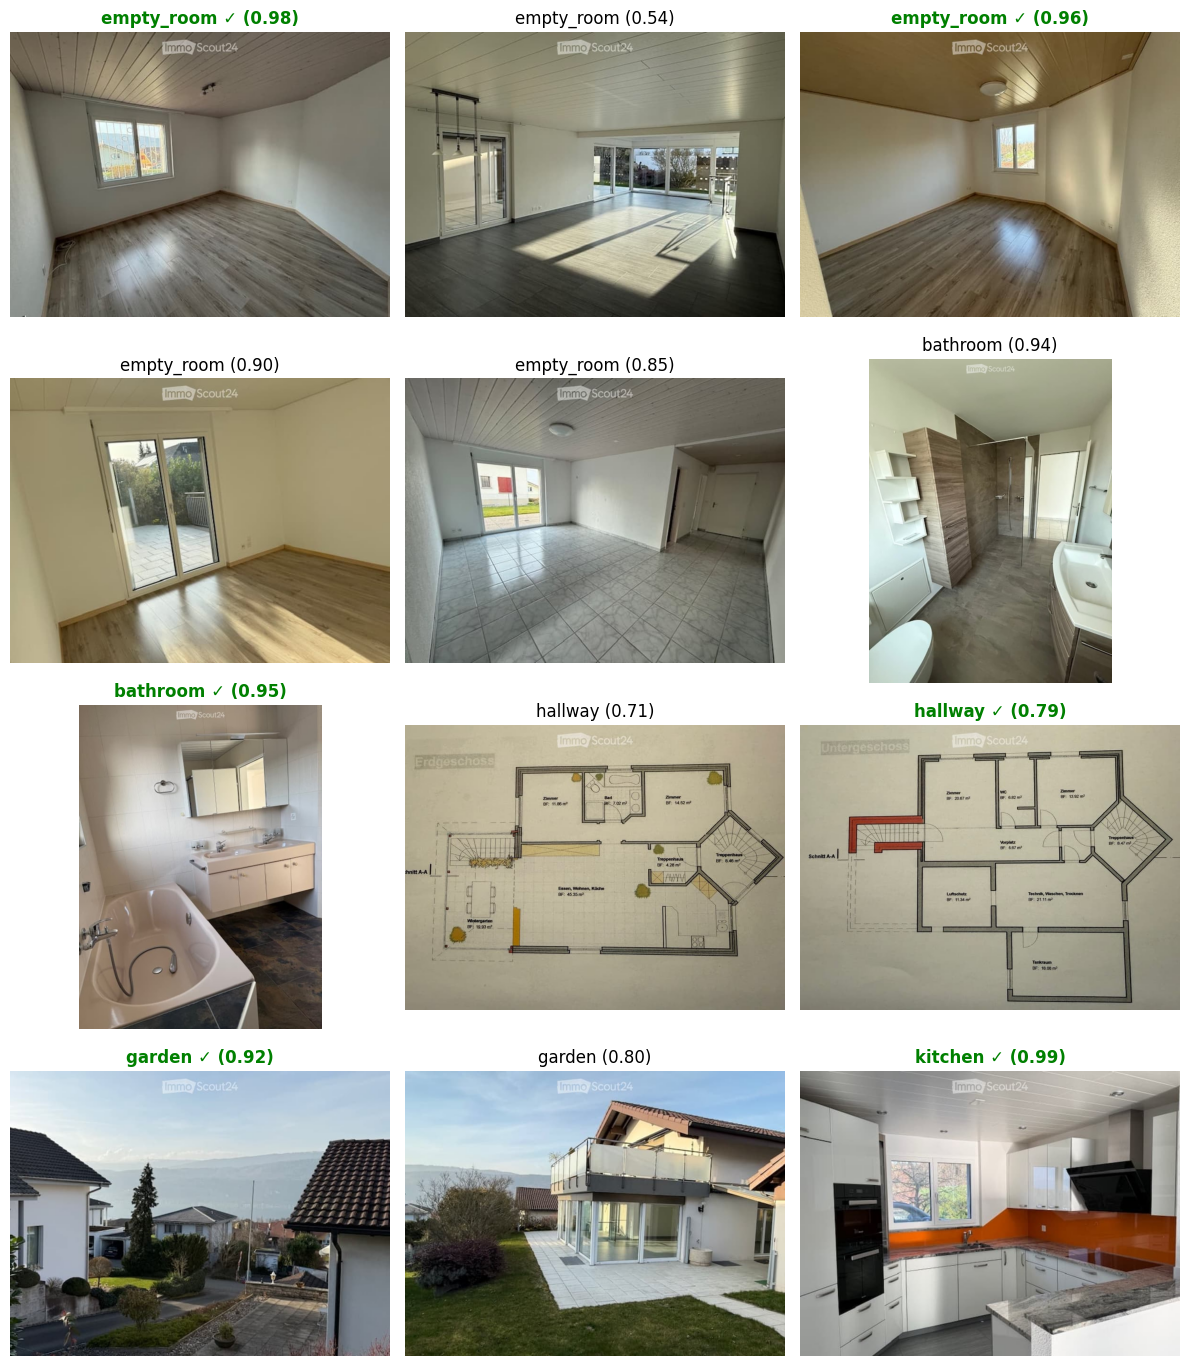

In [ ]:
import json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Set the object id you want to visualize
OBJECT_ID = "4003001679"  # change as needed

# Load processed data
with open("cleaned_apartements_processed.jsonl", "r", encoding="utf-8") as f:
    records = [json.loads(line) for line in f if line.strip()]
    processed = {str(r.get("object_id")): r for r in records}

record = processed.get(OBJECT_ID)
if record is None:
    print("Not found.")
else:
    bin_map = record.get("clip_bin_map", {})
    all_images = []
    for label, imgs in bin_map.items():
        for img in imgs:
            path = img["path"]
            path = path[len("preprocess_pipeline/"):]
            conf = img["confidence"]
            selected = img.get("selected", False)
            all_images.append((path, label, conf, selected))

    n = len(all_images)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
    axes = axes.flatten()

    for ax, (path, label, conf, selected) in zip(axes, all_images):
        try:
            image = Image.open(path)
            ax.imshow(image)
        except Exception as e:
            ax.text(0.5, 0.5, "Error", ha="center", va="center")
        check = " ✓" if selected else ""
        ax.set_title(f"{label}{check} ({conf:.2f})", fontsize=12, color="green" if selected else "black", fontweight="bold" if selected else "normal")
        ax.axis("off")
        for spine in ax.spines.values():
            if selected:
                spine.set_edgecolor("lime")
                spine.set_linewidth(6)
            else:
                spine.set_edgecolor("gray")
                spine.set_linewidth(1)

    for ax in axes[len(all_images):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()